# Deep Agent

`uv add deepagents`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

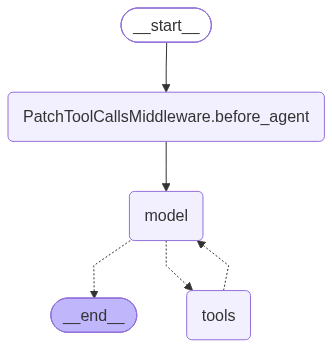

In [ ]:
from deepagents import create_deep_agent
from langchain_tavily import TavilySearch


SYSTEM_PROMPT = """You are an expert researcher. Your job is to conduct thorough research and then write a polished report.
Answer in KOREAN

You have access to an internet search tool as your primary means of gathering information.

## `internet_search`

Use this to run an internet search for a given query. You can specify the max number of results to return, the topic, and whether raw content should be included.
"""

# 모델이 자체적으로 인터넷 검색을 지원 할 경우에는, 아래처럼 tool로 작성 가능
# OpenAI 빌트인 검색
internet_search = {'type': 'web_search'}

tavily = TavilySearch()

agent = create_deep_agent(
    model='openai:gpt-5.4-mini',
    tools=[tavily],
    system_prompt=SYSTEM_PROMPT
)

agent

In [9]:
result = agent.invoke({
    'messages': [
        {'role': 'user', 'content': 'Langchain, Langgraph, DeepAgent 가 뭔지 조사 하고 설명해줘'}
    ]
})

## Deep Research Agent
### Agent
- Prompt
    - 역할 지정
    - Research 업무 순서 지침
    - Subagent 위임 지침
- Tools
    - Tavily Search
    - Think
- Subagent

In [10]:
from dotenv import load_dotenv
load_dotenv()

True

### Tools
```
uv add markdownify tavily
```

In [ ]:
# Tool
"""Research Tools.

This module provides search and content processing utilities for the research agent,
using Tavily for URL discovery and fetching full webpage content.
"""

import httpx
from langchain_core.tools import InjectedToolArg, tool
from markdownify import markdownify
from tavily import TavilyClient
from typing_extensions import Annotated, Literal

tavily_client = TavilyClient()


# 단순 함수 (아래 tool 에서 사용)
def fetch_webpage_content(url: str, timeout: float = 10.0) -> str:
    """Fetch and convert webpage content to markdown.

    Args:
        url: URL to fetch
        timeout: Request timeout in seconds

    Returns:
        Webpage content as markdown
    """
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }

    try:
        response = httpx.get(url, headers=headers, timeout=timeout)
        response.raise_for_status()
        return markdownify(response.text)
    except Exception as e:
        return f"Error fetching content from {url}: {str(e)}"


@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 1,
    topic: Annotated[
        Literal["general", "news", "finance"], InjectedToolArg
    ] = "general",
) -> str:
    """Search the web for information on a given query.

    Uses Tavily to discover relevant URLs, then fetches and returns full webpage content as markdown.

    Args:
        query: Search query to execute
        max_results: Maximum number of results to return (default: 1)
        topic: Topic filter - 'general', 'news', or 'finance' (default: 'general')

    Returns:
        Formatted search results with full webpage content
    """
    # Use Tavily to discover URLs
    search_results = tavily_client.search(
        query,
        max_results=max_results,
        topic=topic,
    )

    # Fetch full content for each URL
    result_texts = []
    for result in search_results.get("results", []):
        url = result["url"]
        title = result["title"]

        # Fetch webpage content
        content = fetch_webpage_content(url)

        result_text = f"""## {title}
**URL:** {url}

{content}

---
"""
        result_texts.append(result_text)

    # Format final response
    response = f"""🔍 Found {len(result_texts)} result(s) for '{query}':

{chr(10).join(result_texts)}"""

    return response


@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"